In [7]:
import numpy as np
from scipy.signal import find_peaks
import sys
import os
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/utils/')
sys.path.append('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/bond_based/')

from plot_utils import plot_cluster_size_distribution, analyze_bond_network, plot_rdfs, plot_3d_cluster_with_graph
from bondmodifier_utils import canonical_cluster_workflow, import_file, summarize_bonds

# Import standardized plotting functions
from standardized_plots import (
    plot_coordination_histograms as std_plot_coordination_histograms,
    plot_graph_structure,
    plot_cluster_size_distribution as std_plot_cluster_size_distribution,
    plot_3d_graph_components,
    plot_3d_graph_components_pu_only as std_plot_3d_graph_components_pu_only,
    setup_plot_style,
    get_standard_colors,
    extract_positions_from_data,
    extract_names_from_data,
)

import numpy as np
import networkx as nx


In [8]:


def get_species_densities_from_data(data):
    """
    Calculate species densities from simulation data.
    
    Parameters:
    -----------
    data : OVITO data object
        Simulation data containing particle information
    
    Returns:
    --------
    dict : Dictionary of species densities {species: density}
    """
    import numpy as np
    
    # Get particle types and names
    particle_types = data.particles.particle_types
    type_names = [particle_types.type_by_id(t).name for t in particle_types]
    
    # Get unique species and counts
    unique_species, counts = np.unique(type_names, return_counts=True)
    
    # Calculate box volume from simulation cell
    cell = data.cell
    if cell is not None:
        cell_matrix = cell.matrix
        volume = np.abs(np.linalg.det(cell_matrix[:3, :3]))
    else:
        raise ValueError("Cannot determine box volume from data")
    
    # Calculate densities
    densities = {}
    for species, count in zip(unique_species, counts):
        densities[species] = count / volume
    
    return densities


In [ ]:
def calculate_coordination_number(r, g_r, rho_j, r1=None, r2=None):
    """
    Calculate coordination number using the formula:
    CN_ij = 4πρ_j ∫[r1 to r2] r² g_ij(r) dr
    
    Parameters:
    -----------
    r : array
        Radial distances
    g_r : array  
        Radial distribution function values
    rho_j : float
        Number density of species j
    r1, r2 : float, optional
        Integration limits. If None, will be determined automatically.
    
    Returns:
    --------
    float : Coordination number
    """
    
    # Determine integration limits if not provided
    if r1 is None or r2 is None:
        # Find first minimum after first peak using scipy
        # Smooth the data slightly
        smooth_window = 5
        g_smooth = np.convolve(g_r, np.ones(smooth_window)/smooth_window, mode='same')
        
        
        # Invert g(r) to find minima as peaks
        g_inverted = -g_smooth
        
        # Find peaks (minima in original) with prominence filtering
        peaks, _ = find_peaks(g_inverted, prominence=0.5, distance=1)
        
        if len(peaks) > 0:
            # Find first minimum after the first peak
            for peak in peaks:
                r2 = r[peak]
                break
            else:
                r2 = r[-1]
        else:
            r2 = r[-1]
        
        r1 = 0.0
    
    # Ensure integration limits are within data range
    r1 = max(r1, r[0])
    r2 = min(r2, r[-1])
    
    # Find indices for integration
    idx1 = np.argmin(np.abs(r - r1))
    idx2 = np.argmin(np.abs(r - r2))
    
    # Ensure idx1 < idx2
    if idx1 >= idx2:
        idx1 = 0
        idx2 = min(idx1 + 10, len(r) - 1)
    
    # Perform integration
    r_integration = r[idx1:idx2+1]
    g_integration = g_r[idx1:idx2+1]
    
    # Calculate coordination number: CN_ij = 4πρ_j ∫ r² g_ij(r) dr
    integrand = 4 * np.pi * rho_j * r_integration**2 * g_integration
    coordination_number = np.trapz(integrand, r_integration)
    
    return coordination_number

In [10]:
# Example usage:
# CN = calculate_coordination_number(r_values, g_values, rho_j)
# 
# Or with manual integration limits:
# CN = calculate_coordination_number(r_values, g_values, rho_j, r1=0.0, r2=3.5)


In [11]:
# User inputs
infile = "/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.27/T1100K/dump.lammpstrj"
rdf_samples = 100  # adjust for speed/accuracy

In [12]:
pipe = import_file(infile, multiple_frames=True)
print(f"Loaded trajectory with {pipe.source.num_frames} frames")

# Set up standardized plotting style
setup_plot_style()
print("Standardized plotting style configured")

# Still construct all bonds (Voronoi and NaCl) but only cluster Pu atoms
result = canonical_cluster_workflow(
    pipeline=pipe,
    # disable_pair=("Na", "Cl"),  # Keep all bonds for construction
    metals=["Pu"],  # Only Pu for cluster analysis, ignoring Na nodes
    anion="Cl",
    rdf_samples=rdf_samples,
)

r = result["rdf"]
cutoffs = result["pair_cutoffs"]
print("Pairwise cutoffs:", cutoffs)

Loaded trajectory with 14615 frames
Standardized plotting style configured
[-3.66043102e-02 -2.26993498e-03  2.05200212e-02  3.17655584e-02
  3.14666766e-02  1.96233758e-02  4.05879959e-02  6.15869123e-02
  4.66660959e-02 -7.38889525e-02 -3.83943331e-01 -9.51495148e-01
 -1.79339055e+00 -2.85462679e+00 -4.04171084e+00 -5.18333270e+00
 -6.13645907e+00 -6.75437261e+00 -6.95688649e+00 -6.78506368e+00
 -6.29672556e+00 -5.61935688e+00 -4.85415359e+00 -4.08440300e+00
 -3.38014297e+00 -2.75858879e+00 -2.24612237e+00 -1.82499451e+00
 -1.47875041e+00 -1.21434579e+00 -9.95175189e-01 -8.32514895e-01
 -7.05703518e-01 -6.06923661e-01 -5.24750188e-01 -4.57704604e-01
 -4.00693331e-01 -3.55770255e-01 -3.22638935e-01 -2.97374701e-01
 -2.74532380e-01 -2.58044548e-01 -2.44588250e-01 -2.38874733e-01
 -2.32411605e-01 -2.28271886e-01 -2.26590438e-01 -2.24238931e-01
 -2.24616233e-01 -2.25177989e-01 -2.25814509e-01 -2.29691312e-01
 -2.35029900e-01 -2.45318801e-01 -2.54450545e-01 -2.64011461e-01
 -2.76442597e-0

In [13]:
names = result["names"]
sizes = result["sizes"]
cluster_ids = result["cluster_ids"]
data0 = result["data"]
G = result["graph"]


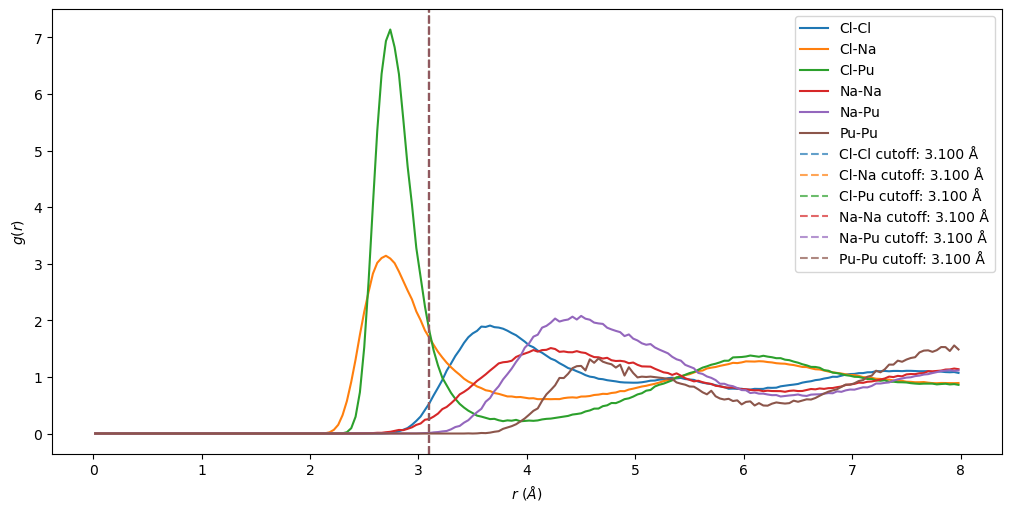

In [14]:
plot_rdfs(result["rdf"], cutoffs=cutoffs,figsize=(10, 5))

In [15]:
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))

{np.str_('Cl'): np.float64(0.01915186620320566),
 np.str_('Na'): np.float64(0.009012642919155605),
 np.str_('Pu'): np.float64(0.0033797410946833518)}

In [16]:
result["rdf"].keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'r'])

In [17]:
calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=3.26)

/tmp/ipykernel_1714818/4031601329.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


np.float64(5.814762194518516)

BOND-BASED COORDINATION HISTOGRAM ANALYSIS
Analyzing coordination for species: [np.str_('Cl'), np.str_('Na'), np.str_('Pu')]

Plotting coordination histogram for Pu:
{np.str_('Cl'): [1, 6, 3, 5, 3, 6, 6, 5, 6, 5, 3, 4, 5, 7, 3, 6, 5, 6, 4, 6, 2, 3, 4, 4, 6, 5, 5, 2, 3, 4, 6, 6, 4, 5, 2, 6, 6, 6, 5, 6, 4, 6, 3, 6, 5, 5, 5, 6, 5, 6, 6, 5, 6, 5, 5, 4, 5, 5, 5, 5, 6, 5, 6, 5, 5, 3, 5, 5, 6, 6, 5, 5, 5, 3, 4, 6, 5, 6, 6, 7, 6, 5, 5, 6, 6, 5, 5, 6, 4, 5, 6, 5, 5, 4, 4, 4, 4, 4, 5, 3, 5, 7, 6, 6, 6, 4, 5, 6, 7, 5, 5, 5, 6, 5, 4, 5, 4, 5, 4, 5, 5, 5, 5, 6, 4, 6, 4, 5, 4, 5, 5, 5, 4, 6, 5, 5, 5, 4, 6, 6, 6, 6, 6, 6, 6, 5, 3, 5, 5, 6, 5, 4, 7, 5, 7, 4, 3, 3, 4, 2, 5, 5, 4, 3, 6, 7, 4, 4, 7, 7, 5, 6, 4, 5, 5, 5, 3, 6, 6, 6, 5, 6, 5, 5, 6, 4, 6, 5, 6, 6, 5, 2, 3, 5, 4, 6, 5, 6, 5, 5, 6, 5, 5, 5, 5, 5, 6, 6, 6, 3, 5, 6, 6, 5, 6, 5, 6, 4, 5, 4, 6, 4, 6, 7, 5, 4, 7, 4, 6, 5, 5, 5, 5, 5, 5, 6, 5, 3, 6, 5, 6, 6, 5, 6, 6, 3, 6, 5, 6, 5, 4, 5, 6, 5, 4, 4, 4, 2, 5, 4, 6, 6, 6, 5, 5, 5, 5, 5, 6, 6, 5, 7, 6

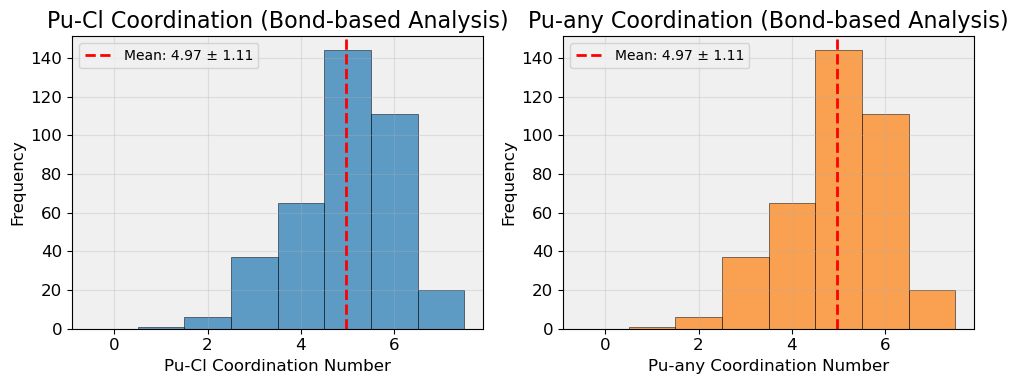


Plotting coordination histogram for Na:
{np.str_('Cl'): [1, 1, 2, 2, 3, 3, 2, 3, 2, 3, 2, 3, 3, 3, 2, 1, 2, 1, 2, 1, 3, 3, 3, 3, 2, 3, 2, 2, 4, 3, 2, 2, 3, 1, 3, 4, 4, 4, 2, 3, 5, 2, 3, 2, 3, 2, 2, 3, 4, 2, 3, 1, 2, 4, 2, 2, 3, 2, 2, 1, 4, 3, 2, 2, 2, 2, 4, 2, 4, 2, 1, 2, 1, 2, 4, 3, 4, 3, 3, 3, 2, 2, 2, 3, 4, 3, 3, 2, 2, 0, 3, 4, 3, 3, 3, 1, 4, 4, 3, 3, 3, 3, 3, 2, 5, 5, 5, 5, 3, 4, 3, 3, 3, 2, 4, 4, 4, 4, 4, 2, 4, 2, 3, 4, 4, 3, 3, 3, 5, 3, 3, 4, 3, 2, 4, 4, 5, 4, 2, 4, 2, 3, 4, 4, 5, 2, 4, 5, 3, 3, 4, 3, 3, 3, 3, 4, 2, 3, 3, 3, 4, 3, 4, 4, 4, 1, 1, 3, 3, 4, 3, 1, 3, 0, 2, 4, 4, 2, 1, 2, 5, 3, 4, 3, 2, 3, 3, 3, 4, 4, 3, 4, 2, 5, 3, 2, 2, 3, 3, 5, 4, 4, 4, 3, 3, 4, 3, 3, 3, 4, 2, 4, 5, 4, 3, 5, 3, 2, 4, 4, 2, 5, 2, 4, 3, 4, 3, 4, 3, 5, 2, 6, 3, 3, 2, 2, 5, 3, 5, 4, 3, 3, 3, 4, 4, 3, 1, 3, 4, 3, 2, 2, 2, 3, 5, 5, 2, 3, 2, 2, 3, 2, 3, 2, 2, 3, 3, 5, 4, 4, 4, 4, 3, 4, 3, 4, 4, 4, 5, 3, 5, 4, 3, 4, 4, 3, 2, 4, 5, 3, 3, 4, 2, 3, 2, 3, 5, 3, 4, 2, 4, 3, 5, 1, 4, 3, 3, 3, 3, 4, 4, 2, 4, 2, 

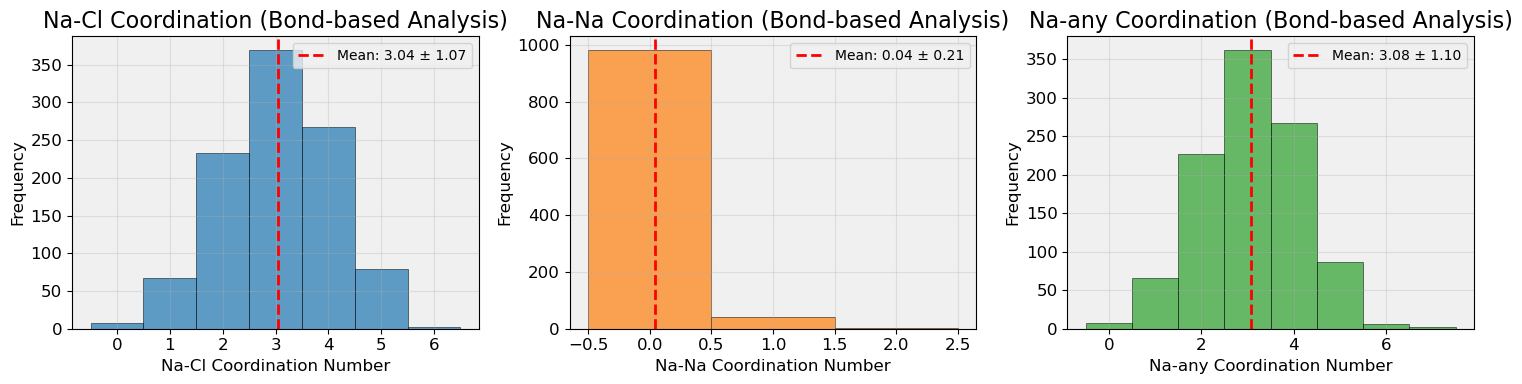


Plotting coordination histogram for Cl:
{np.str_('Cl'): [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

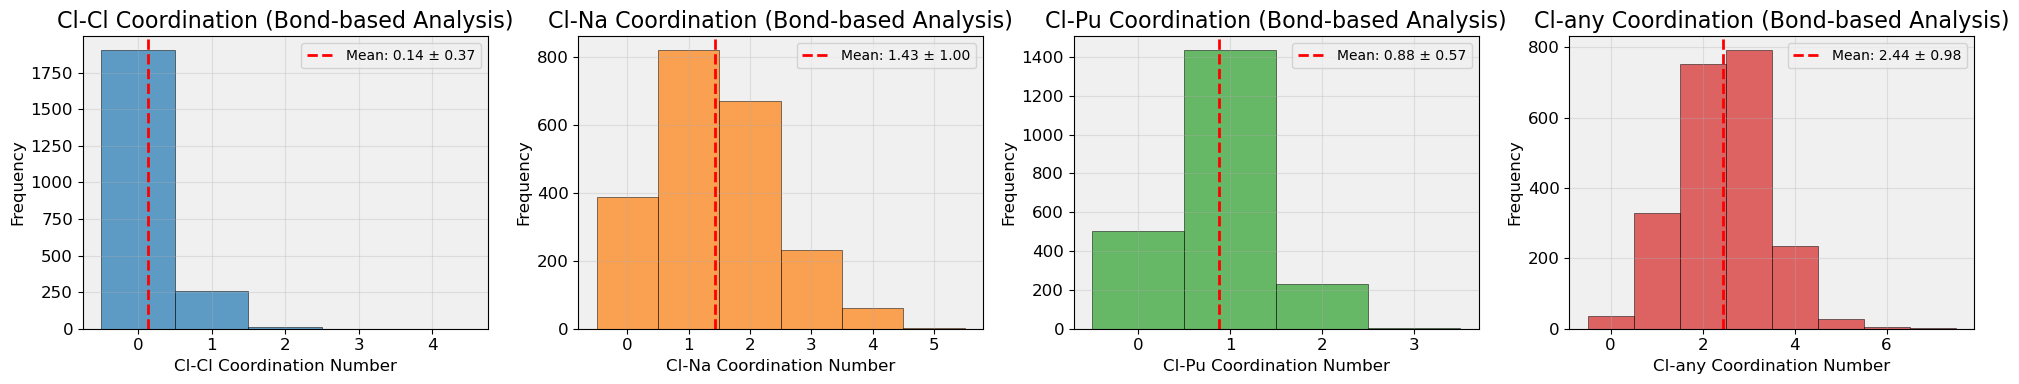


BOND-BASED COORDINATION ANALYSIS COMPLETE


In [18]:
def analyze_bond_coordination(data, names, pair_cutoffs=None):
    """
    Analyze coordination using bond-based analysis (similar to analyze_voronoi_coordination).
    
    This function computes neighbor-count distributions by species using bond cutoffs
    instead of Voronoi tessellation, making it suitable for bond-based cluster analysis.
    
    Parameters:
        data: OVITO data object containing particle information
        names: Array of atom names/types
        pair_cutoffs: Dictionary of bond cutoffs for different species pairs
    
    Returns:
        dict: Coordination data organized by central species and neighbor species
              Includes additional 'any' coordination structures:
              - coord_data[sp_c]['any']: total coordination for each central species
              - coord_data['any'][sp_n]: coordination from any central species to each neighbor species
              - coord_data['any']['any']: total coordination across all species pairs
    """
    import numpy as np
    from collections import defaultdict
    
    # Get unique species
    unique_species = sorted(list(set(names)))
    print(f"Analyzing coordination for species: {unique_species}")
    
    # Initialize coordination data structure
    coord_data = {sp_c: {sp_n: [] for sp_n in unique_species} for sp_c in unique_species}
    
    # Add 'any' coordination structures
    coord_data['any'] = {sp_n: [] for sp_n in unique_species}
    coord_data['any']['any'] = []
    
    # Get positions and create species mapping
    positions = data.particles.positions[:]
    species_idx = {sp: i for i, sp in enumerate(unique_species)}
    
    # Create species array for each atom
    atom_species = np.array([species_idx[name] for name in names])
    
    # Calculate coordination for each atom
    for i, (pos_i, sp_i) in enumerate(zip(positions, names)):
        neighbors = []
        
        # Find neighbors within cutoff distance
        for j, (pos_j, sp_j) in enumerate(zip(positions, names)):
            if i == j:
                continue
                
            # Calculate distance
            dist = np.linalg.norm(pos_j - pos_i)
            
            # Check if within cutoff (use default or specific pair cutoff)
            if pair_cutoffs:
                cutoff_key = (sp_i, sp_j)
                if cutoff_key in pair_cutoffs:
                    cutoff = pair_cutoffs[cutoff_key]
                else:
                    # Use default cutoff if specific pair not found
                    cutoff = 4.0  # Default cutoff
            else:
                cutoff = 4.0  # Default cutoff
                
            if dist <= cutoff:
                neighbors.append(sp_j)
        
        # Store coordination counts for specific species pairs
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data[sp_i][neighbor_sp].append(count)
        
        # Store total coordination for this central species (any neighbors)
        total_coord = len(neighbors)
        coord_data[sp_i]['any'] = coord_data[sp_i].get('any', [])
        coord_data[sp_i]['any'].append(total_coord)
        
        # Store coordination counts for 'any' central species to each neighbor species
        for neighbor_sp in unique_species:
            count = neighbors.count(neighbor_sp)
            coord_data['any'][neighbor_sp].append(count)
        
        # Store total coordination for 'any'-'any' (all coordination)
        coord_data['any']['any'].append(total_coord)
    
    return coord_data

def plot_bond_coordination_histograms(coord_data, central_species, title_suffix=""):
    """
    Plot coordination histograms for bond-based analysis.
    
    Parameters:
        coord_data: Coordination data from analyze_bond_coordination
        central_species: Species to plot coordination for
        title_suffix: Optional suffix for plot title
    """
    import matplotlib.pyplot as plt
    import numpy as np
    
    if central_species not in coord_data:
        print(f"No coordination data found for species: {central_species}")
        return
    
    # Get coordination data for the central species
    species_data = coord_data[central_species]
    print(species_data)
    
    # Filter out empty neighbor species
    neighbor_species = [sp for sp, counts in species_data.items() if counts and any(counts)]
    print(neighbor_species)
    
    if not neighbor_species:
        print(f"No coordination data found for {central_species}")
        return
    
    # Create subplots
    n_neighbors = len(neighbor_species)
    fig, axes = plt.subplots(1, n_neighbors, figsize=(5*n_neighbors, 4))
    if n_neighbors == 1:
        axes = [axes]
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
    
    for idx, neighbor_sp in enumerate(neighbor_species):
        counts = species_data[neighbor_sp]
        
        if not counts:
            continue
            
        # Create histogram
        max_coord = max(counts) if counts else 0
        bins = np.arange(0, max_coord + 2) - 0.5
        
        axes[idx].hist(counts, bins=bins, alpha=0.7, color=colors[idx % len(colors)], 
                      edgecolor='black', linewidth=0.5)
        
        # Add statistics
        mean_coord = np.mean(counts)
        std_coord = np.std(counts)
        axes[idx].axvline(mean_coord, color='red', linestyle='--', linewidth=2, 
                         label=f'Mean: {mean_coord:.2f} ± {std_coord:.2f}')
        
        axes[idx].set_xlabel(f'{central_species}-{neighbor_sp} Coordination Number')
        axes[idx].set_ylabel('Frequency')
        axes[idx].set_title(f'{central_species}-{neighbor_sp} Coordination{title_suffix}')
        axes[idx].legend()
        axes[idx].grid(True, alpha=0.3)
        
        # Print statistics
        print(f'{central_species}-{neighbor_sp}: {mean_coord:.2f} ± {std_coord:.2f} (n={len(counts)})')
    
    plt.tight_layout()
    plt.show()

# Test the coordination analysis with current data
print("=" * 60)
print("BOND-BASED COORDINATION HISTOGRAM ANALYSIS")
print("=" * 60)

# Analyze coordination using bond cutoffs
coord_data = analyze_bond_coordination(data0, names, pair_cutoffs=cutoffs)

# Plot coordination histograms for each species
for species in ['Pu', 'Na', 'Cl']:
    if species in coord_data and any(any(counts) for counts in coord_data[species].values()):
        print(f"\nPlotting coordination histogram for {species}:")
        plot_bond_coordination_histograms(coord_data, species, " (Bond-based Analysis)")
    else:
        print(f"No coordination data available for {species}")

print("\n" + "=" * 60)
print("BOND-BASED COORDINATION ANALYSIS COMPLETE")
print("=" * 60)


In [19]:
cutoffs

{('Pu', 'Cl'): 3.1,
 ('Pu', 'Na'): 3.1,
 ('Pu', 'Pu'): 3.1,
 ('Cl', 'Pu'): 3.1,
 ('Cl', 'Na'): 3.1,
 ('Cl', 'Cl'): 3.1,
 ('Na', 'Pu'): 3.1,
 ('Na', 'Cl'): 3.1,
 ('Na', 'Na'): 3.1}

In [14]:
CN_pu_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
CN_pu_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Pu', 'Na')])
CN_pu_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Pu-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Pu', 'Pu')])

/tmp/ipykernel_971410/4031601329.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [15]:
CN_na_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Na', 'Cl')])
CN_na_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Na', 'Na')])
CN_na_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Na-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Na', 'Pu')])

/tmp/ipykernel_971410/4031601329.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [16]:
CN_cl_cl=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Cl"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Cl"],r1=0.0,r2=cutoffs[('Cl', 'Cl')])
CN_cl_na=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Na"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Na"],r1=0.0,r2=cutoffs[('Cl', 'Na')])
CN_cl_pu=calculate_coordination_number(result["rdf"]["r"], result["rdf"]["Cl-Pu"], get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))["Pu"],r1=0.0,r2=cutoffs[('Cl', 'Pu')])

/tmp/ipykernel_971410/4031601329.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


In [17]:
# Create a comprehensive comparison table of coordination numbers
import pandas as pd

print("=" * 80)
print("COORDINATION NUMBER COMPARISON: RDF INTEGRATION vs HISTOGRAM ANALYSIS")
print("=" * 80)

# Extract coordination numbers from RDF integration
rdf_cn_values = {
    'Pu-Cl': CN_pu_cl,
    'Pu-Na': CN_pu_na, 
    'Pu-Pu': CN_pu_pu,
    'Na-Cl': CN_na_cl,
    'Na-Na': CN_na_na,
    'Na-Pu': CN_na_pu,
    'Cl-Cl': CN_cl_cl,
    'Cl-Na': CN_cl_na,
    'Cl-Pu': CN_cl_pu
}

# Extract coordination numbers from histogram analysis
histogram_cn_values = {}

# Calculate mean coordination numbers from histogram data
for central_sp in ['Pu', 'Na', 'Cl']:
    if central_sp in coord_data:
        for neighbor_sp in ['Pu', 'Na', 'Cl']:
            if neighbor_sp in coord_data[central_sp] and coord_data[central_sp][neighbor_sp]:
                counts = coord_data[central_sp][neighbor_sp]
                mean_cn = np.mean(counts)
                std_cn = np.std(counts)
                pair_key = f"{central_sp}-{neighbor_sp}"
                histogram_cn_values[pair_key] = {
                    'mean': mean_cn,
                    'std': std_cn,
                    'count': len(counts)
                }

# Create comparison table
comparison_data = []
for pair in sorted(rdf_cn_values.keys()):
    rdf_val = rdf_cn_values[pair]
    
    if pair in histogram_cn_values:
        hist_mean = histogram_cn_values[pair]['mean']
        hist_std = histogram_cn_values[pair]['std']
        hist_count = histogram_cn_values[pair]['count']
        difference = rdf_val - hist_mean
        percent_diff = (difference / hist_mean) * 100 if hist_mean != 0 else 0
    else:
        hist_mean = "N/A"
        hist_std = "N/A"
        hist_count = "N/A"
        difference = "N/A"
        percent_diff = "N/A"
    
    comparison_data.append({
        'Pair': pair,
        'RDF Integration': f"{rdf_val:.3f}",
        'Histogram Mean': f"{hist_mean:.3f}" if isinstance(hist_mean, (int, float)) else hist_mean,
        'Histogram Std': f"{hist_std:.3f}" if isinstance(hist_std, (int, float)) else hist_std,
        'Histogram Count': hist_count,
        'Difference': f"{difference:.3f}" if isinstance(difference, (int, float)) else difference,
        'Percent Diff': f"{percent_diff:.1f}%" if isinstance(percent_diff, (int, float)) else percent_diff
    })

# Create DataFrame and display
df_comparison = pd.DataFrame(comparison_data)
print("\nDetailed Comparison Table:")
print(df_comparison.to_string(index=False))

print("\n" + "=" * 80)
print("SUMMARY STATISTICS")
print("=" * 80)

# Calculate summary statistics for pairs where both methods have data
valid_pairs = []
for pair in rdf_cn_values.keys():
    if pair in histogram_cn_values:
        valid_pairs.append(pair)

if valid_pairs:
    differences = []
    percent_diffs = []
    
    for pair in valid_pairs:
        rdf_val = rdf_cn_values[pair]
        hist_val = histogram_cn_values[pair]['mean']
        diff = rdf_val - hist_val
        percent_diff = (diff / hist_val) * 100 if hist_val != 0 else 0
        differences.append(diff)
        percent_diffs.append(percent_diff)
    
    print(f"Number of comparable pairs: {len(valid_pairs)}")
    print(f"Mean absolute difference: {np.mean(np.abs(differences)):.3f}")
    print(f"Mean absolute percent difference: {np.mean(np.abs(percent_diffs)):.1f}%")
    print(f"Max absolute difference: {np.max(np.abs(differences)):.3f}")
    print(f"Max absolute percent difference: {np.max(np.abs(percent_diffs)):.1f}%")

print("\n" + "=" * 80)
print("CUTOFF VALUES USED")
print("=" * 80)
for pair, cutoff in cutoffs.items():
    print(f"{pair[0]}-{pair[1]}: {cutoff:.3f} Å")

print("\n" + "=" * 80)
print("SPECIES DENSITIES")
print("=" * 80)
densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))
for species, density in densities.items():
    print(f"{species}: {density:.6f} atoms/Å³")


COORDINATION NUMBER COMPARISON: RDF INTEGRATION vs HISTOGRAM ANALYSIS

Detailed Comparison Table:
 Pair RDF Integration Histogram Mean Histogram Std  Histogram Count Difference Percent Diff
Cl-Cl           0.139          0.135         0.373             2176      0.004         3.1%
Cl-Na           1.536          1.432         0.999             2176      0.104         7.3%
Cl-Pu           0.941          0.878         0.574             2176      0.063         7.2%
Na-Cl           3.264          3.042         1.066             1024      0.222         7.3%
Na-Na           0.046          0.043         0.208             1024      0.003         7.4%
Na-Pu           0.000          0.000         0.000             1024      0.000         0.0%
Pu-Cl           5.332          4.974         1.111              384      0.358         7.2%
Pu-Na           0.001          0.000         0.000              384      0.001         0.0%
Pu-Pu           0.000          0.000         0.000              384      0

In [18]:
# Calculate CN_*_any (total coordination for each central species)
print("=" * 60)
print("CALCULATING CN_*_any (Total Coordination for Each Central Species)")
print("=" * 60)

# Method 1: Sum individual CN values
CN_pu_any_rdf = CN_pu_cl + CN_pu_na + CN_pu_pu
CN_na_any_rdf = CN_na_cl + CN_na_na + CN_na_pu  
CN_cl_any_rdf = CN_cl_cl + CN_cl_na + CN_cl_pu

print("From RDF Integration (sum of individual CNs):")
print(f"CN_Pu_any = CN_Pu_Cl + CN_Pu_Na + CN_Pu_Pu = {CN_pu_cl:.3f} + {CN_pu_na:.3f} + {CN_pu_pu:.3f} = {CN_pu_any_rdf:.3f}")
print(f"CN_Na_any = CN_Na_Cl + CN_Na_Na + CN_Na_Pu = {CN_na_cl:.3f} + {CN_na_na:.3f} + {CN_na_pu:.3f} = {CN_na_any_rdf:.3f}")
print(f"CN_Cl_any = CN_Cl_Cl + CN_Cl_Na + CN_Cl_Pu = {CN_cl_cl:.3f} + {CN_cl_na:.3f} + {CN_cl_pu:.3f} = {CN_cl_any_rdf:.3f}")

# # Method 2: Calculate from histogram data
# print("\nFrom Histogram Analysis:")
# if 'any' in coord_data:
#     for central_sp in ['Pu', 'Na', 'Cl']:
#         if central_sp in coord_data and 'any' in coord_data[central_sp]:
#             counts = coord_data[central_sp]['any']
#             mean_cn = np.mean(counts)
#             std_cn = np.std(counts)
#             print(f"CN_{central_sp}_any = {mean_cn:.3f} ± {std_cn:.3f} (n={len(counts)})")
#         else:
#             print(f"CN_{central_sp}_any: No data available")

# print("\n" + "=" * 60)
# print("CALCULATING CN_any_* (Coordination from Any Central Species)")
# print("=" * 60)

# # Method 1: Sum individual CN values (weighted by species fractions)
# densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))
# total_density = sum(densities.values())
# species_fractions = {sp: densities[sp]/total_density for sp in densities.keys()}

# print("Species fractions:")
# for sp, frac in species_fractions.items():
#     print(f"{sp}: {frac:.3f}")

# print("\nFrom RDF Integration (weighted sum):")
# CN_any_cl_rdf = species_fractions['Pu'] * CN_pu_cl + species_fractions['Na'] * CN_na_cl + species_fractions['Cl'] * CN_cl_cl
# CN_any_na_rdf = species_fractions['Pu'] * CN_pu_na + species_fractions['Na'] * CN_na_na + species_fractions['Cl'] * CN_cl_na
# CN_any_pu_rdf = species_fractions['Pu'] * CN_pu_pu + species_fractions['Na'] * CN_na_pu + species_fractions['Cl'] * CN_cl_pu

# print(f"CN_any_Cl = {species_fractions['Pu']:.3f}×{CN_pu_cl:.3f} + {species_fractions['Na']:.3f}×{CN_na_cl:.3f} + {species_fractions['Cl']:.3f}×{CN_cl_cl:.3f} = {CN_any_cl_rdf:.3f}")
# print(f"CN_any_Na = {species_fractions['Pu']:.3f}×{CN_pu_na:.3f} + {species_fractions['Na']:.3f}×{CN_na_na:.3f} + {species_fractions['Cl']:.3f}×{CN_cl_na:.3f} = {CN_any_na_rdf:.3f}")
# print(f"CN_any_Pu = {species_fractions['Pu']:.3f}×{CN_pu_pu:.3f} + {species_fractions['Na']:.3f}×{CN_na_pu:.3f} + {species_fractions['Cl']:.3f}×{CN_cl_pu:.3f} = {CN_any_pu_rdf:.3f}")

# # Method 2: Calculate from histogram data
# print("\nFrom Histogram Analysis:")
# if 'any' in coord_data:
#     for neighbor_sp in ['Pu', 'Na', 'Cl']:
#         if neighbor_sp in coord_data['any']:
#             counts = coord_data['any'][neighbor_sp]
#             mean_cn = np.mean(counts)
#             std_cn = np.std(counts)
#             print(f"CN_any_{neighbor_sp} = {mean_cn:.3f} ± {std_cn:.3f} (n={len(counts)})")
#         else:
#             print(f"CN_any_{neighbor_sp}: No data available")

# print("\n" + "=" * 60)
# print("CALCULATING CN_any_any (Total Coordination)")
# print("=" * 60)

# # Method 1: Sum all individual CN values (weighted)
# CN_any_any_rdf = CN_any_cl_rdf + CN_any_na_rdf + CN_any_pu_rdf
# print(f"From RDF Integration: CN_any_any = {CN_any_cl_rdf:.3f} + {CN_any_na_rdf:.3f} + {CN_any_pu_rdf:.3f} = {CN_any_any_rdf:.3f}")

# # Method 2: Calculate from histogram data
# if 'any' in coord_data and 'any' in coord_data['any']:
#     counts = coord_data['any']['any']
#     mean_cn = np.mean(counts)
#     std_cn = np.std(counts)
#     print(f"From Histogram Analysis: CN_any_any = {mean_cn:.3f} ± {std_cn:.3f} (n={len(counts)})")

# print("\n" + "=" * 60)
# print("SUMMARY OF ALL COORDINATION NUMBERS")
# print("=" * 60)

# # Create a comprehensive summary
# summary_data = {
#     'CN_Pu_any': {'RDF': CN_pu_any_rdf, 'Histogram': coord_data.get('Pu', {}).get('any', [])},
#     'CN_Na_any': {'RDF': CN_na_any_rdf, 'Histogram': coord_data.get('Na', {}).get('any', [])},
#     'CN_Cl_any': {'RDF': CN_cl_any_rdf, 'Histogram': coord_data.get('Cl', {}).get('any', [])},
#     'CN_any_Cl': {'RDF': CN_any_cl_rdf, 'Histogram': coord_data.get('any', {}).get('Cl', [])},
#     'CN_any_Na': {'RDF': CN_any_na_rdf, 'Histogram': coord_data.get('any', {}).get('Na', [])},
#     'CN_any_Pu': {'RDF': CN_any_pu_rdf, 'Histogram': coord_data.get('any', {}).get('Pu', [])},
#     'CN_any_any': {'RDF': CN_any_any_rdf, 'Histogram': coord_data.get('any', {}).get('any', [])}
# }

# for cn_type, data in summary_data.items():
#     rdf_val = data['RDF']
#     hist_data = data['Histogram']
    
#     if hist_data and len(hist_data) > 0:
#         hist_mean = np.mean(hist_data)
#         hist_std = np.std(hist_data)
#         diff = rdf_val - hist_mean
#         percent_diff = (diff / hist_mean) * 100 if hist_mean != 0 else 0
#         print(f"{cn_type:12}: RDF={rdf_val:6.3f}, Hist={hist_mean:6.3f}±{hist_std:5.3f}, Diff={diff:+6.3f} ({percent_diff:+5.1f}%)")
#     else:
#         print(f"{cn_type:12}: RDF={rdf_val:6.3f}, Hist=N/A")


CALCULATING CN_*_any (Total Coordination for Each Central Species)
From RDF Integration (sum of individual CNs):
CN_Pu_any = CN_Pu_Cl + CN_Pu_Na + CN_Pu_Pu = 5.332 + 0.001 + 0.000 = 5.333
CN_Na_any = CN_Na_Cl + CN_Na_Na + CN_Na_Pu = 3.264 + 0.046 + 0.000 = 3.310
CN_Cl_any = CN_Cl_Cl + CN_Cl_Na + CN_Cl_Pu = 0.139 + 1.536 + 0.941 = 2.616


In [19]:
from bondmodifier_utils import canonical_cluster_workflow_rdfs_only

In [ ]:
# Comprehensive coordination number analysis for all x & T combinations
import glob
import re
import json
import pickle
from pathlib import Path
from tqdm.auto import tqdm
print("=" * 80)
print("COMPREHENSIVE COORDINATION NUMBER + RDF ANALYSIS")
print("=" * 80)

# Get all dump files
file_list = glob.glob('/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x*/T*/dump.lammpstrj')
print(f"Found {len(file_list)} files to process")

# Initialize results dictionary
coordination_results = {}
rdf_data_all = {}

# Process each file
for i in tqdm(range(len(file_list))):
    infile = file_list[i]
    print(f"\nProcessing file {i+1}/{len(file_list)}: {infile}")
    
    # Extract x and T from file path
    path_parts = infile.split('/')
    x_part = None
    T_part = None
    
    for part in path_parts:
        if part.startswith('x') and '.' in part:
            x_part = part
        elif part.startswith('T') and 'K' in part:
            T_part = part
    
    if not x_part or not T_part:
        print(f"  Warning: Could not extract x and T from {infile}")
        continue
    
    # Extract numerical values
    x_match = re.search(r'x(\d+\.?\d*)', x_part)
    T_match = re.search(r'T(\d+)K', T_part)
    
    if not x_match or not T_match:
        print(f"  Warning: Could not parse x and T values from {x_part}, {T_part}")
        continue
    
    x_val = float(x_match.group(1))
    T_val = int(T_match.group(1))
    
    print(f"  Processing x={x_val}, T={T_val}K")
    
    try:
        # Load pipeline
        pipe = import_file(infile, multiple_frames=True)
        print(f"    Loaded {pipe.source.num_frames} frames")
        
        # Generate RDFs and cutoffs
        result = canonical_cluster_workflow_rdfs_only(
            pipeline=pipe,
            rdf_samples=100,
        )
        
        rdf_data = result["rdf"]
        cutoffs = result["pair_cutoffs"]
        
        # Get species densities
        densities = get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))
        
        # Store RDF data (convert numpy arrays to lists for JSON serialization)
        rdf_data_serializable = {}
        for key, value in rdf_data.items():
            if isinstance(value, np.ndarray):
                rdf_data_serializable[key] = value.tolist()
            else:
                rdf_data_serializable[key] = value
        
        rdf_data_all[(x_val, T_val)] = {
            'x': x_val,
            'T': T_val,
            'file': infile,
            'rdf_data': rdf_data_serializable,
            'cutoffs': cutoffs,
            'densities': densities
        }
        
        # Calculate individual coordination numbers
        cn_values = {}
        
        # Individual CN calculations
        cn_pairs = [
            ('Pu', 'Cl'), ('Pu', 'Na'), ('Pu', 'Pu'),
            ('Na', 'Cl'), ('Na', 'Na'), ('Na', 'Pu'),
            ('Cl', 'Cl'), ('Cl', 'Na'), ('Cl', 'Pu')
        ]
        
        for central, neighbor in cn_pairs:
            try:
                # Create alphabetically sorted RDF key (e.g., Pu-Cl becomes Cl-Pu)
                rdf_key = '-'.join(sorted([central, neighbor]))
                if rdf_key in rdf_data and neighbor in densities:
                    cn_val = calculate_coordination_number(
                        rdf_data["r"], 
                        rdf_data[rdf_key], 
                        densities[neighbor],
                        r1=0.0, 
                        r2=cutoffs[(central, neighbor)]
                    )
                    cn_values[f"CN_{central}_{neighbor}"] = cn_val
                else:
                    cn_values[f"CN_{central}_{neighbor}"] = np.nan
            except Exception as e:
                print(f"    Error calculating CN_{central}_{neighbor}: {e}")
                cn_values[f"CN_{central}_{neighbor}"] = np.nan
        
        # Calculate total coordination numbers (CN_*_any)
        cn_values["CN_Pu_any"] = cn_values["CN_Pu_Cl"] + cn_values["CN_Pu_Na"] + cn_values["CN_Pu_Pu"]
        cn_values["CN_Na_any"] = cn_values["CN_Na_Cl"] + cn_values["CN_Na_Na"] + cn_values["CN_Na_Pu"]
        cn_values["CN_Cl_any"] = cn_values["CN_Cl_Cl"] + cn_values["CN_Cl_Na"] + cn_values["CN_Cl_Pu"]
        
        # Store results
        coordination_results[(x_val, T_val)] = {
            'file': infile,
            'x': x_val,
            'T': T_val,
            'cutoffs': cutoffs,
            'densities': densities,
            'coordination_numbers': cn_values
        }
        
        print(f"    Successfully calculated coordination numbers and stored RDF data")
        
    except Exception as e:
        print(f"    Error processing {infile}: {e}")
        # Store NaN values for failed cases
        cn_values = {}
        for central in ['Pu', 'Na', 'Cl']:
            for neighbor in ['Pu', 'Na', 'Cl']:
                cn_values[f"CN_{central}_{neighbor}"] = np.nan
        cn_values["CN_Pu_any"] = np.nan
        cn_values["CN_Na_any"] = np.nan
        cn_values["CN_Cl_any"] = np.nan
        
        coordination_results[(x_val, T_val)] = {
            'file': infile,
            'x': x_val,
            'T': T_val,
            'cutoffs': None,
            'densities': None,
            'coordination_numbers': cn_values
        }
        
        # Store empty RDF data for failed cases
        rdf_data_all[(x_val, T_val)] = {
            'x': x_val,
            'T': T_val,
            'file': infile,
            'rdf_data': None,
            'cutoffs': None,
            'densities': None
        }

print(f"\nCompleted processing {len(coordination_results)} files")

# Create summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)

# Sort by x, then T
sorted_results = sorted(coordination_results.items(), key=lambda x: (x[0][0], x[0][1]))

# Create DataFrame for easy viewing
import pandas as pd

summary_data = []
for (x, T), data in sorted_results:
    cn_data = data['coordination_numbers']
    row = {
        'x': x,
        'T': T,
        'CN_Pu_Cl': cn_data['CN_Pu_Cl'],
        'CN_Pu_Na': cn_data['CN_Pu_Na'],
        'CN_Pu_Pu': cn_data['CN_Pu_Pu'],
        'CN_Na_Cl': cn_data['CN_Na_Cl'],
        'CN_Na_Na': cn_data['CN_Na_Na'],
        'CN_Na_Pu': cn_data['CN_Na_Pu'],
        'CN_Cl_Cl': cn_data['CN_Cl_Cl'],
        'CN_Cl_Na': cn_data['CN_Cl_Na'],
        'CN_Cl_Pu': cn_data['CN_Cl_Pu'],
        'CN_Pu_any': cn_data['CN_Pu_any'],
        'CN_Na_any': cn_data['CN_Na_any'],
        'CN_Cl_any': cn_data['CN_Cl_any']
    }
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
print(df_summary.to_string(index=False, float_format='%.3f'))

# Save coordination numbers to JSON file
cn_output_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/coordination_numbers_all_x_T.json'
with open(cn_output_file, 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    json_data = {}
    for (x, T), data in coordination_results.items():
        json_data[f"x{x}_T{T}"] = {
            'x': float(x),
            'T': int(T),
            'file': data['file'],
            'coordination_numbers': {k: float(v) if not np.isnan(v) else None for k, v in data['coordination_numbers'].items()}
        }
    json.dump(json_data, f, indent=2)

# Save RDF data to JSON file
rdf_output_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/rdf_data_all_x_T.json'
with open(rdf_output_file, 'w') as f:
    json.dump(rdf_data_all, f, indent=2)

# Also save RDF data as pickle for better numpy array preservation
rdf_pickle_file = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/cluster_analysis/rdf_data_all_x_T.pkl'
with open(rdf_pickle_file, 'wb') as f:
    pickle.dump(rdf_data_all, f)

print(f"\nResults saved to:")
print(f"  Coordination numbers: {cn_output_file}")
print(f"  RDF data (JSON): {rdf_output_file}")
print(f"  RDF data (Pickle): {rdf_pickle_file}")
print(f"Total files processed: {len(coordination_results)}")
print(f"Successful calculations: {sum(1 for data in coordination_results.values() if data['cutoffs'] is not None)}")
print(f"Failed calculations: {sum(1 for data in coordination_results.values() if data['cutoffs'] is None)}")

# Show RDF data structure
print(f"\nRDF data structure:")
if rdf_data_all:
    sample_key = list(rdf_data_all.keys())[0]
    sample_data = rdf_data_all[sample_key]
    if sample_data['rdf_data'] is not None:
        print(f"  Sample RDF keys: {list(sample_data['rdf_data'].keys())}")
        print(f"  R-axis length: {len(sample_data['rdf_data']['r'])}")
        print(f"  RDF pairs: {[k for k in sample_data['rdf_data'].keys() if k != 'r' and k != 'complete']}")
    else:
        print("  No RDF data available in sample")


COMPREHENSIVE COORDINATION NUMBER + RDF ANALYSIS
Found 76 files to process


  0%|          | 0/76 [00:00<?, ?it/s]


Processing file 1/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1200K/dump.lammpstrj
  Processing x=0.4, T=1200K
    Loaded 25057 frames


/tmp/ipykernel_971410/4031601329.py:70: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  coordination_number = np.trapz(integrand, r_integration)


    Successfully calculated coordination numbers and stored RDF data

Processing file 2/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1100K/dump.lammpstrj
  Processing x=0.4, T=1100K
    Loaded 24588 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 3/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T800K/dump.lammpstrj
  Processing x=0.4, T=800K
    Loaded 23530 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 4/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1300K/dump.lammpstrj
  Processing x=0.4, T=1300K
    Loaded 25431 frames
    Successfully calculated coordination numbers and stored RDF data

Processing file 5/76: /pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.40/T1000K/dump.lammpstrj
  Processing x=0.4, T=1000K
    Loaded 24515 frames
    Successfully calculated coordination numbers and stored RDF da

TypeError: keys must be str, int, float, bool or None, not tuple

In [ ]:
from matplotlib import pyplot as plt

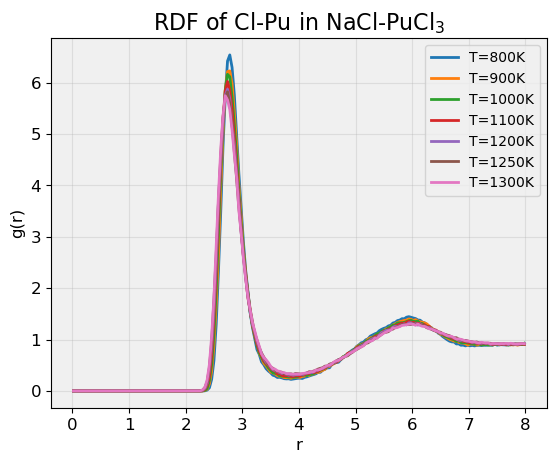

In [ ]:
pucl_rdfs=dict()
pucl_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        pucl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Cl-Pu']
        pucl_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(pucl_rdfs.keys()):
    plt.plot(pucl_rs[key], pucl_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Cl-Pu in NaCl-PuCl$_3$')
plt.show()


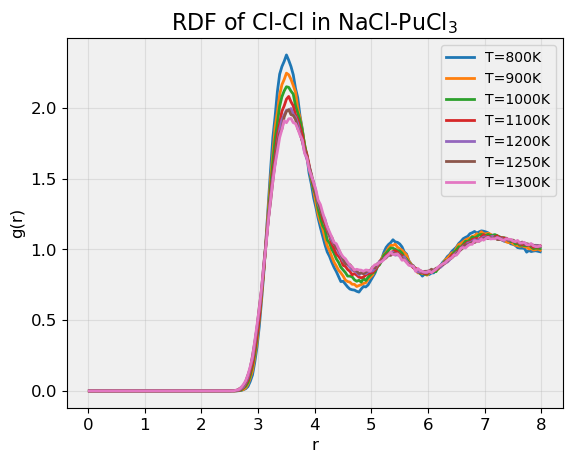

In [50]:
clcl_rdfs=dict()
clcl_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        clcl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Cl-Cl']
        clcl_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(clcl_rdfs.keys()):
    plt.plot(clcl_rs[key], clcl_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Cl-Cl in NaCl-PuCl$_3$')
plt.show()


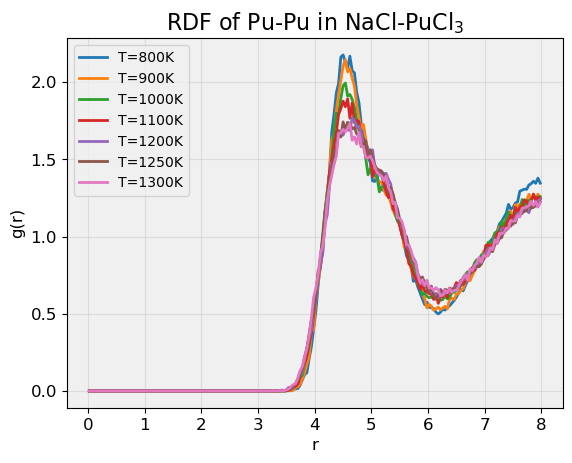

In [51]:
pupu_rdfs=dict()
pupu_rs=dict()
for key in rdf_data_all.keys():
    if key[0] == 0.67:
        pupu_rdfs[key[1]]=rdf_data_all[key]['rdf_data']['Pu-Pu']
        pupu_rs[key[1]]=rdf_data_all[key]['rdf_data']['r']

for key in sorted(pupu_rdfs.keys()):
    plt.plot(pupu_rs[key], pupu_rdfs[key], label=f'T={key}K')
plt.legend()
# plt.ylim(0, 3)
plt.xlabel('r')
plt.ylabel('g(r)')
plt.title('RDF of Pu-Pu in NaCl-PuCl$_3$')
plt.show()


In [35]:
rdf_data_all[(0.67, 800)].keys()

dict_keys(['x', 'T', 'file', 'rdf_data', 'cutoffs', 'densities'])

In [37]:
rdf_data_all[(0.67, 800)]['rdf_data'].keys()

dict_keys(['Na-Na', 'Cl-Na', 'Na-Pu', 'Cl-Cl', 'Cl-Pu', 'Pu-Pu', 'complete', 'r'])

In [56]:

dpucl_rdfs=dict()
# dpucl_rs=dict()
dpucl_CN=dict()
dpucl_densities=dict()

for key in rdf_data_all.keys():
    if key[0] == 0.67:
        dpucl_rdfs[key[1]]=rdf_data_all[key]['rdf_data']
        dpucl_CN[key[1]]=dict()
        dpucl_densities[key[1]]=rdf_data_all[key]['densities']


        CN_pu_cl=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Cl-Pu"], dpucl_densities[key[1]]["Cl"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        CN_pu_na=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Na-Pu"], dpucl_densities[key[1]]["Na"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        CN_pu_pu=calculate_coordination_number(dpucl_rdfs[key[1]]["r"], dpucl_rdfs[key[1]]["Pu-Pu"], dpucl_densities[key[1]]["Pu"],r1=0.0,r2=cutoffs[('Pu', 'Cl')])
        dpucl_CN[key[1]]["CN_Pu_Cl"]=CN_pu_cl
        dpucl_CN[key[1]]["CN_Pu_Na"]=CN_pu_na
        dpucl_CN[key[1]]["CN_Pu_Pu"]=CN_pu_pu
        dpucl_CN[key[1]]["CN_Pu_any"]=CN_pu_cl+CN_pu_na+CN_pu_pu



TypeError: unsupported operand type(s) for -: 'list' and 'float'

dpucl_densities

In [53]:
infile = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T800K/dump.lammpstrj'
pipe = import_file(infile, multiple_frames=True)
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))



{np.str_('Cl'): np.float64(0.023959924398009456),
 np.str_('Na'): np.float64(0.0034228463425727794),
 np.str_('Pu'): np.float64(0.006845692685145559)}

In [54]:
infile = '/pscratch/sd/p/pvashi/irp/irp_mace_l_2/irp/density/NaCl-PuCl3/x0.67/T1200K/dump.lammpstrj'
pipe = import_file(infile, multiple_frames=True)
get_species_densities_from_data(pipe.compute(pipe.source.num_frames-1))



{np.str_('Cl'): np.float64(0.021543845362447748),
 np.str_('Na'): np.float64(0.003077692194635393),
 np.str_('Pu'): np.float64(0.006155384389270786)}